<h1 style="text-align:center; font-family: 'Segoe UI', Arial, sans-serif; color:#00BFFF; font-size:46px;">
🚀 Spaceship Titanic 🚀
</h1>


##  Table of Contents

* [Introduction](#introduction)
* [Objective](#objective)
* [1. Exploratory Data Analysis (EDA)](#1-exploratory-data-analysis-eda)
    * [1.1 Data Overview](#11-data-overview)
    * [1.2 Missing Values Analysis](#12-missing-values-analysis)
    * [1.3 Correlation Analysis](#13-correlation-analysis)
    * [1.4 Target Variable & Categorical Data Analysis](#14-target-variable--categorical-data-analysis)
    * [1.5 Distribution Shape Analysis](#15-distribution-shape-analysis)
    * [1.6 Numerical Data Analysis](#16-numerical-data-analysis)
    * [1.7 Outlier Analysis](#17-outlier-analysis)
    * [1.8 Feature Relationships Analysis](#18-feature-relationships-analysis)
    * [1.9 Mutual Information / Feature Importance](#19-mutual-information--feature-importance)

<div style="text-align: center; background-color: #e0e0e0; border: 2px solid #888888; border-radius: 10px; padding: 15px; margin: 20px 0;">
  <h2 style="color: #222222; font-family: Arial, sans-serif;">1. Exploratory Data Analysis</h2>
</div>

# 1.1 Data Overview 

<div style="border-left:5px solid #3498DB; background-color:rgba(52,152,219,0.08); padding:12px; border-radius:6px; color:inherit;">
    In this section, I examined the <b>basic structure, dimensions, missing values, and descriptive statistics</b> of the dataset. 
    This serves as an <i>initial exploration step</i> to guide the next stages of feature engineering and modeling.
</div>

<br>

<h3 style="color:inherit;"> Dataset Summary</h3>
<ul style="color:inherit;">
  <li><b>Train set:</b> 8,693 rows × 14 columns</li>
  <li><b>Test set:</b> 4,277 rows × 13 columns</li>
  <li><b>Data Types:</b> <code>bool (1)</code>, <code>float64 (6)</code>, <code>object (7)</code></li>
</ul>

<div style="border-left:5px solid #F39C12; background-color:rgba(243,156,18,0.08); padding:10px; border-radius:6px; color:inherit;">
    Almost all variables contain <b>missing values</b>. 
    My goal will be to <b>minimize information loss</b> during imputation, and where possible, 
    <b>enhance the dataset’s feature richness</b> to capture hidden relationships.
</div>

<br>

<h3 style="color:inherit;"> Descriptive Statistics Interpretation</h3>

<h4 style="color:#5DADE2;">🔹 Age</h4>
<p style="margin-left:10px; color:inherit;">
The <b>mean age</b> of passengers is <b>28</b>, suggesting a relatively young demographic.  
The <b>standard deviation (14)</b> indicates a moderate spread around the mean.  
Moreover, the <b>mean and median are close</b>, implying the distribution is <i>approximately symmetric</i> and not heavily skewed — a favorable characteristic for modeling.
</p>

<h4 style="color:#5DADE2;">🔹 Spending Columns</h4>
<p style="margin-left:10px; color:inherit;">
(<code>RoomService</code>, <code>FoodCourt</code>, <code>ShoppingMall</code>, <code>Spa</code>, <code>VRDeck</code>)  
The <b>standard deviations are much higher</b> than their respective means, clearly suggesting <b>extreme outliers</b> in spending patterns.  
This deviation from normality implies that <i>robust scaling or transformation methods</i> may be necessary in later preprocessing steps.
</p>

<br>

<div style="border-left:5px solid #2E86C1; background-color:rgba(46,134,193,0.08); padding:12px; border-radius:6px; color:inherit;">
    <b>Takeaway:</b><br>
    The dataset exhibits a balanced structure but shows considerable variation and missingness across numerical features.  
    The next step will involve <b>handling missing values</b> and <b>detecting outliers</b> to ensure the foundation for feature engineering and modeling is statistically sound.
</div>


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from   matplotlib.patches import Rectangle
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv("/kaggle/input/spaceship-titanic/train.csv")
test = pd.read_csv("/kaggle/input/spaceship-titanic/test.csv")

In [3]:
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print("\nFirst 5 rows of train data:")
display(train.head())

Train shape: (8693, 14)
Test shape: (4277, 13)

First 5 rows of train data:


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [4]:
train.info()
print()
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count 

In [5]:
 train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [6]:
test.isnull().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [7]:
train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [8]:
test.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,4186.000000,4195.000000,4171.000000,4179.000000,4176.000000,4197.000000
mean,28.658146,219.266269,439.484296,177.295525,303.052443,310.710031
std,14.179072,607.011289,1527.663045,560.821123,1117.186015,1246.994742
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,37.000000,53.000000,78.000000,33.000000,50.000000,36.000000
max,79.000000,11567.000000,25273.000000,8292.000000,19844.000000,22272.000000


In [9]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [10]:
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

for col in cat_cols:
    train_counts = train[col].value_counts(normalize=True) * 100
    test_counts = test[col].value_counts(normalize=True) * 100
     
    train_counts.name = 'train_%'
    test_counts.name = 'test_%'
   
    compare = pd.concat([train_counts, test_counts], axis=1).fillna(0)
    
    print(f"\n==== {col} ====")
    print(compare.round(2))



==== HomePlanet ====
            train_%  test_%
HomePlanet                 
Earth         54.19   54.01
Europa        25.09   23.91
Mars          20.71   22.08

==== CryoSleep ====
           train_%  test_%
CryoSleep                 
False        64.17    63.1
True         35.83    36.9

==== Destination ====
               train_%  test_%
Destination                   
TRAPPIST-1e      69.50   70.63
55 Cancri e      21.15   20.10
PSO J318.5-22     9.35    9.27

==== VIP ====
       train_%  test_%
VIP                   
False    97.66   98.23
True      2.34    1.77


# 1.2 Missing Values Analysis

<div style="font-family:'Segoe UI', Roboto, Arial, sans-serif; color: var(--text-color, #e5e7eb); line-height:1.6; max-width:900px;">
 
  <p style="color:#d1d5db;">
    Both the <strong>train</strong> and <strong>test</strong> datasets show a very similar missing data structure, 
    with approximately <strong>2%</strong> of values missing per column. 
    This similarity suggests that the data was likely generated or collected through the same underlying process or algorithm.
  </p>

  <p style="color:#d1d5db;">
    Given the low rate of missingness and the consistency across datasets, 
    using a <strong>machine learning–based imputation</strong> approach may be more effective than simple statistical methods 
    such as mean, median, or mode filling.  
    Leveraging the <em>relationships between variables</em> to predict and fill in missing values can help preserve 
    data variability and potentially improve downstream model performance.
  </p>

  <div style="border-left:4px solid #60a5fa; background-color:rgba(96,165,250,0.08); padding:0.8rem 1rem; border-radius:6px; margin-top:0.8rem;">
    <strong style="color:#bfdbfe;">Insight:</strong>
    <span style="display:block; margin-top:0.4rem; color:#e5e7eb;">
      The consistent missing pattern across train and test sets supports the assumption of a unified data generation mechanism. 
      ML-driven imputation (e.g., <code>KNNImputer</code>, <code>IterativeImputer</code>) can utilize multivariate dependencies to fill gaps more intelligently, 
      minimizing data loss and preserving predictive power.
    </span>
  </div>

</div>


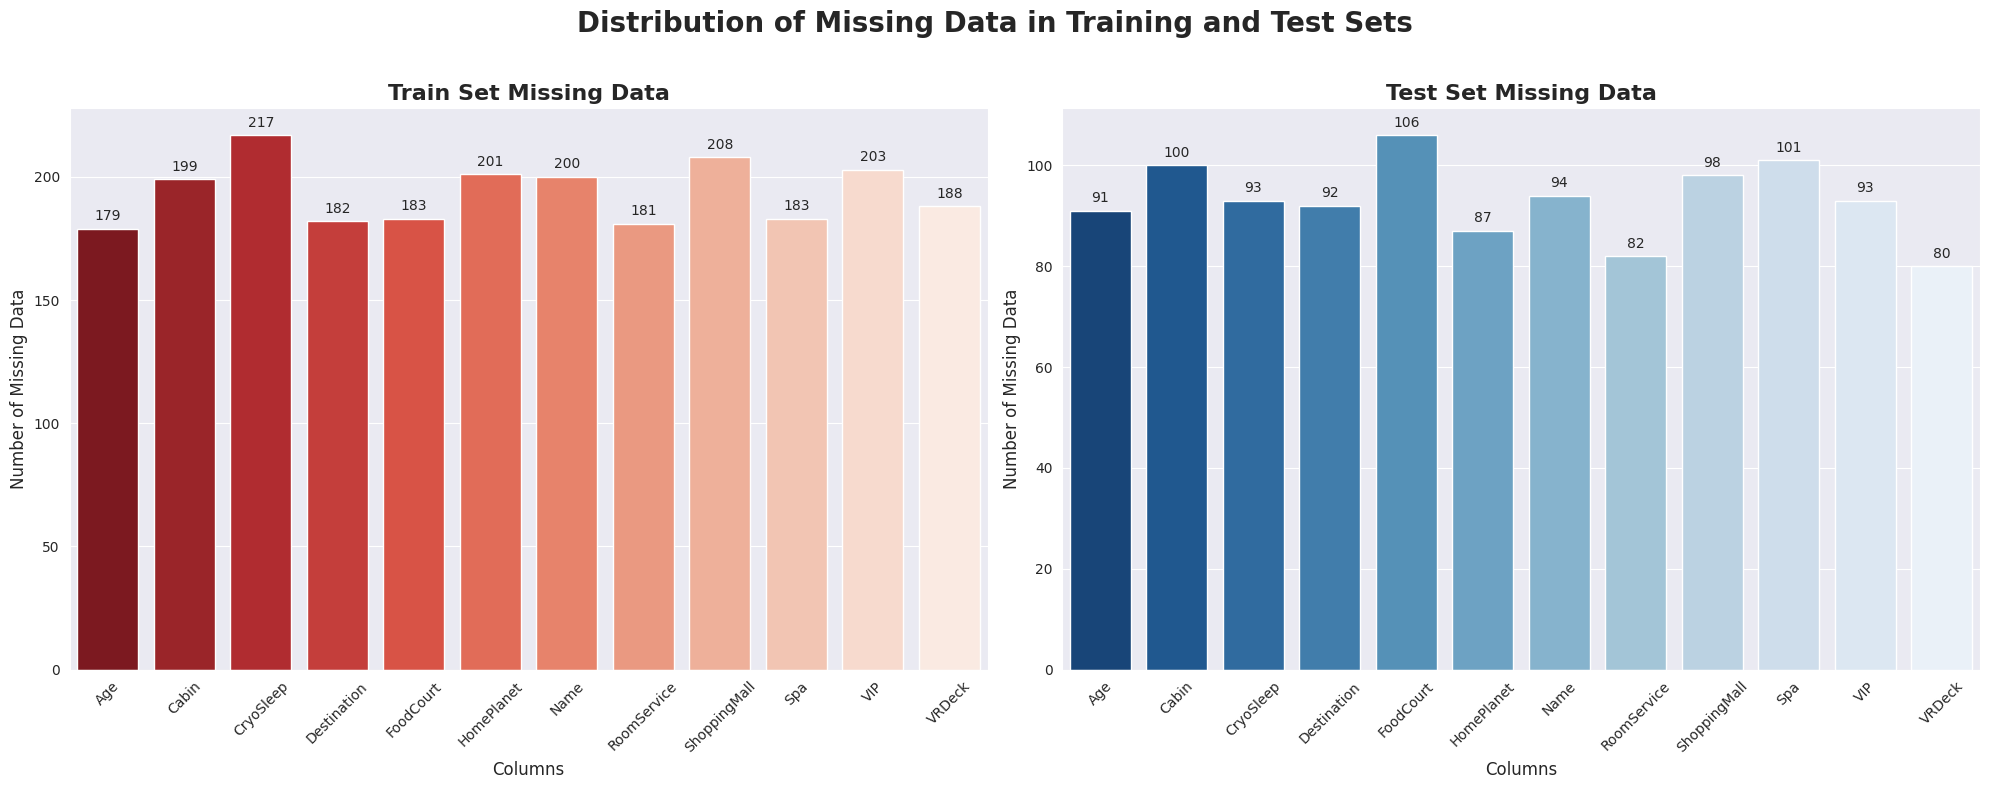

In [11]:
missing_train = train.isnull().sum()
missing_test = test.isnull().sum()

 
missing_df = pd.DataFrame({
    'Train Missing': missing_train,
    'Test Missing': missing_test
}).fillna(0).astype(int)  

 
missing_df = missing_df[(missing_df['Train Missing'] > 0) | (missing_df['Test Missing'] > 0)]

 
sns.set_style("darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Distribution of Missing Data in Training and Test Sets', fontsize=20, weight='bold')

 
sns.barplot(x=missing_df.index, y=missing_df['Train Missing'], ax=axes[0], palette='Reds_r')
axes[0].set_title('Train Set Missing Data', fontsize=16, weight='bold')
axes[0].set_ylabel('Number of Missing Data', fontsize=12)
axes[0].set_xlabel('Columns', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=10)

 
sns.barplot(x=missing_df.index, y=missing_df['Test Missing'], ax=axes[1], palette='Blues_r')
axes[1].set_title('Test Set Missing Data', fontsize=16, weight='bold')
axes[1].set_ylabel('Number of Missing Data', fontsize=12)
axes[1].set_xlabel('Columns', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 1.3 Correlation Analysis

<div style="font-family: 'Segoe UI', Roboto, Arial, sans-serif; color: var(--text-color, #e5e7eb); line-height:1.6; max-width:900px;">


  <p style="color:#d1d5db;">
    The correlation analysis shows a few weak yet noteworthy relationships between the numerical spending features and the target variable <strong>Transported</strong>. 
    Overall, most features are weakly correlated, indicating low multicollinearity and diverse feature behavior — ideal conditions for building a stable model.
  </p>

  <div style="border-left:4px solid #60a5fa; background-color:rgba(96,165,250,0.08); padding:0.8rem 1rem; border-radius:6px; margin-top:0.8rem;">
    <strong style="color:#bfdbfe;">Insight:</strong>
    <span style="display:block; margin-top:0.4rem; color:#e5e7eb;">
        <h3 style="color:#93c5fd; margin-top:1rem; margin-bottom:0.3rem;">Train Set</h3>
  <ul style="color:#d1d5db; margin-top:0.3rem; margin-bottom:0.8rem;">
    <li><strong>RoomService, Spa, VRDeck → Transported</strong>: Around <strong>−0.20</strong> (weak negative). This suggests passengers spending less on these amenities might be slightly more likely to be <em>Transported</em>.</li>
    <li><strong>VRDeck, Spa, FoodCourt</strong>: About <strong>+0.20</strong> correlation, implying that spending behaviors on these services are somewhat aligned — people spending on one tend to spend on others as well.</li>
    <li><em>Observation:</em> Most correlations are close to zero, confirming feature independence and low multicollinearity risk.</li>
  </ul>
    <h3 style="color:#93c5fd; margin-top:1rem; margin-bottom:0.3rem;">Test Set</h3>
  <p style="color:#d1d5db;">
    The test set reflects a similar correlation pattern to the training data. 
    Notably, <strong>Spa–FoodCourt</strong> and <strong>VRDeck–FoodCourt</strong> maintain weak positive relationships (~+0.20), suggesting consistent spending patterns and feature distribution between datasets.
  </p>
    </span>
  </div>

</div>


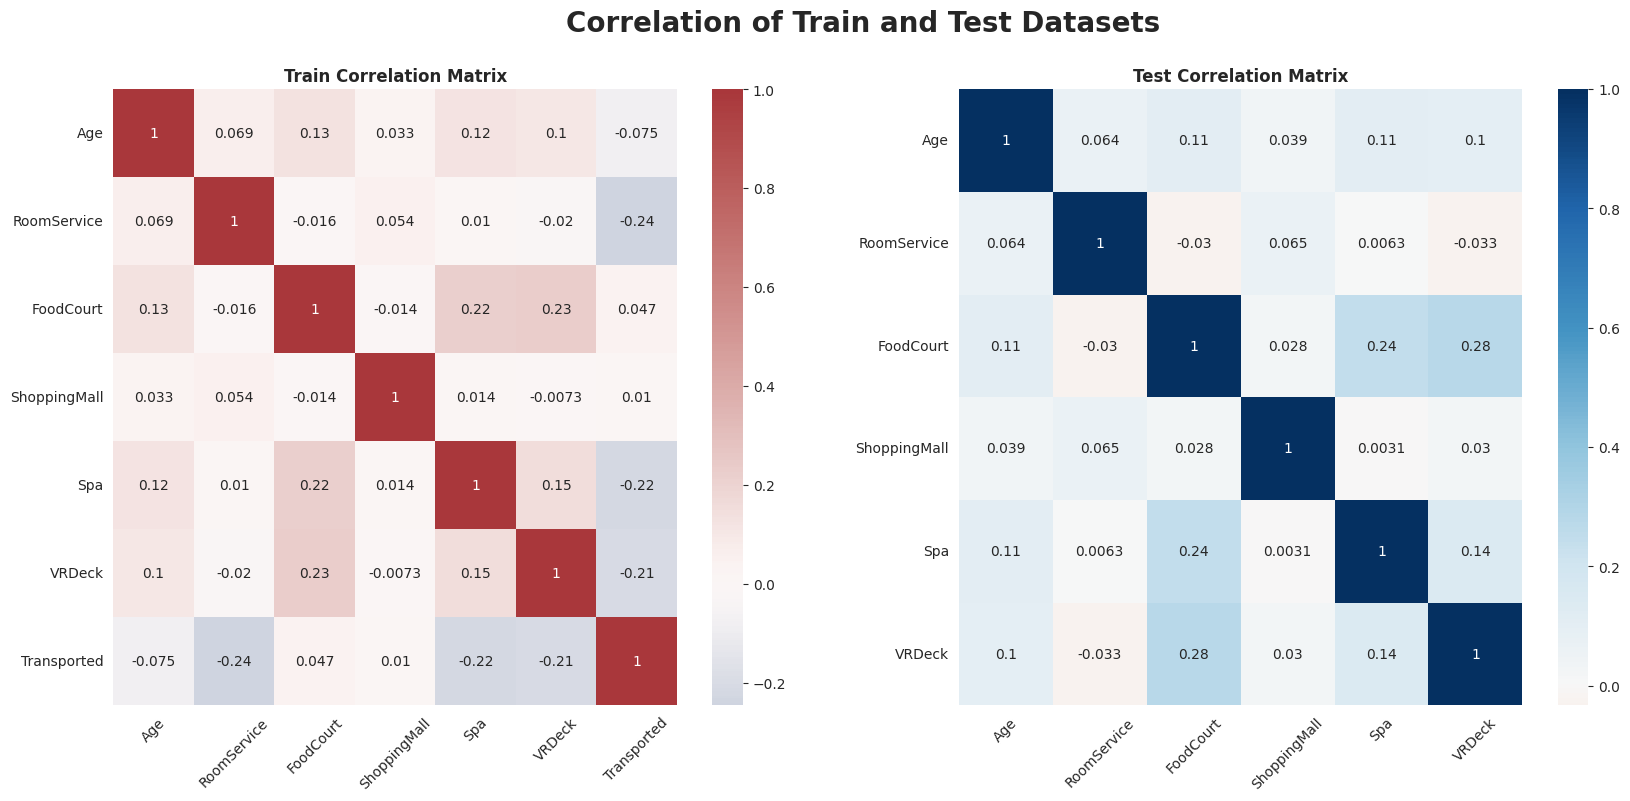

In [12]:
corr_train = train.corr(numeric_only=True)
corr_test = test.corr(numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Correlation of Train and Test Datasets', fontsize=20, weight='bold')

sns.heatmap(corr_train, ax=axes[0], cmap='vlag',annot = True, center=0)
axes[0].set_title('Train Correlation Matrix', weight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(corr_test, ax=axes[1], cmap='RdBu', annot =True, center=0)
axes[1].set_title('Test Correlation Matrix', weight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.show()

# 1.4 Target Variable Analysis and Categorical Data Analysis

<div style="font-family:'Segoe UI', Roboto, Arial, sans-serif; line-height:1.65; color:var(--text-color, #e5e7eb); max-width:900px; background-color:var(--bg-color, transparent);"> <div style="border-left:4px solid #818cf8; background-color:rgba(129,140,248,0.08); padding:1.2rem 1.4rem; border-radius:10px;"> <h3 style="color:#a5b4fc; font-weight:600; margin-top:0; margin-bottom:0.8rem; font-size:1.25rem;"> Key Insights on Categorical Features </h3> <ul style="list-style-type:none; padding-left:0; color:#d1d5db; margin:0;"> <li style="margin-bottom:1.1rem;"> <strong style="color:#a78bfa;">HomePlanet:</strong>


The distributions for this feature are highly similar in both datasets. Passengers from <em>Europa</em> exhibit the highest transport rate, indicating that <strong>HomePlanet</strong> could be a meaningful predictor in determining transport outcomes. </li> <li style="margin-bottom:1.1rem;"> <strong style="color:#a78bfa;">CryoSleep:</strong>


Passengers in cryosleep (<em>CryoSleep=True</em>) show a remarkably high transport rate of approximately <strong>81%</strong>. This clear separation suggests a strong relationship with the target variable, making it one of the most influential categorical predictors. </li> <li style="margin-bottom:1.1rem;"> <strong style="color:#a78bfa;">VIP:</strong>


The transported rate for VIP passengers is around <strong>38%</strong>, which is notably lower than that of non-VIPs. However, given that the VIP group forms a small subset of the dataset, its predictive influence is expected to remain limited. </li> <li> <strong style="color:#a78bfa;">Destination:</strong>


While the majority of passengers are traveling to <em>TRAPPIST-1e</em>, those bound for <em>55 Cancri e</em> have the highest transported rate. This hints at a potential statistical link between destination and transport likelihood, though caution is advised due to smaller sample sizes. </li> </ul> </div> </div>

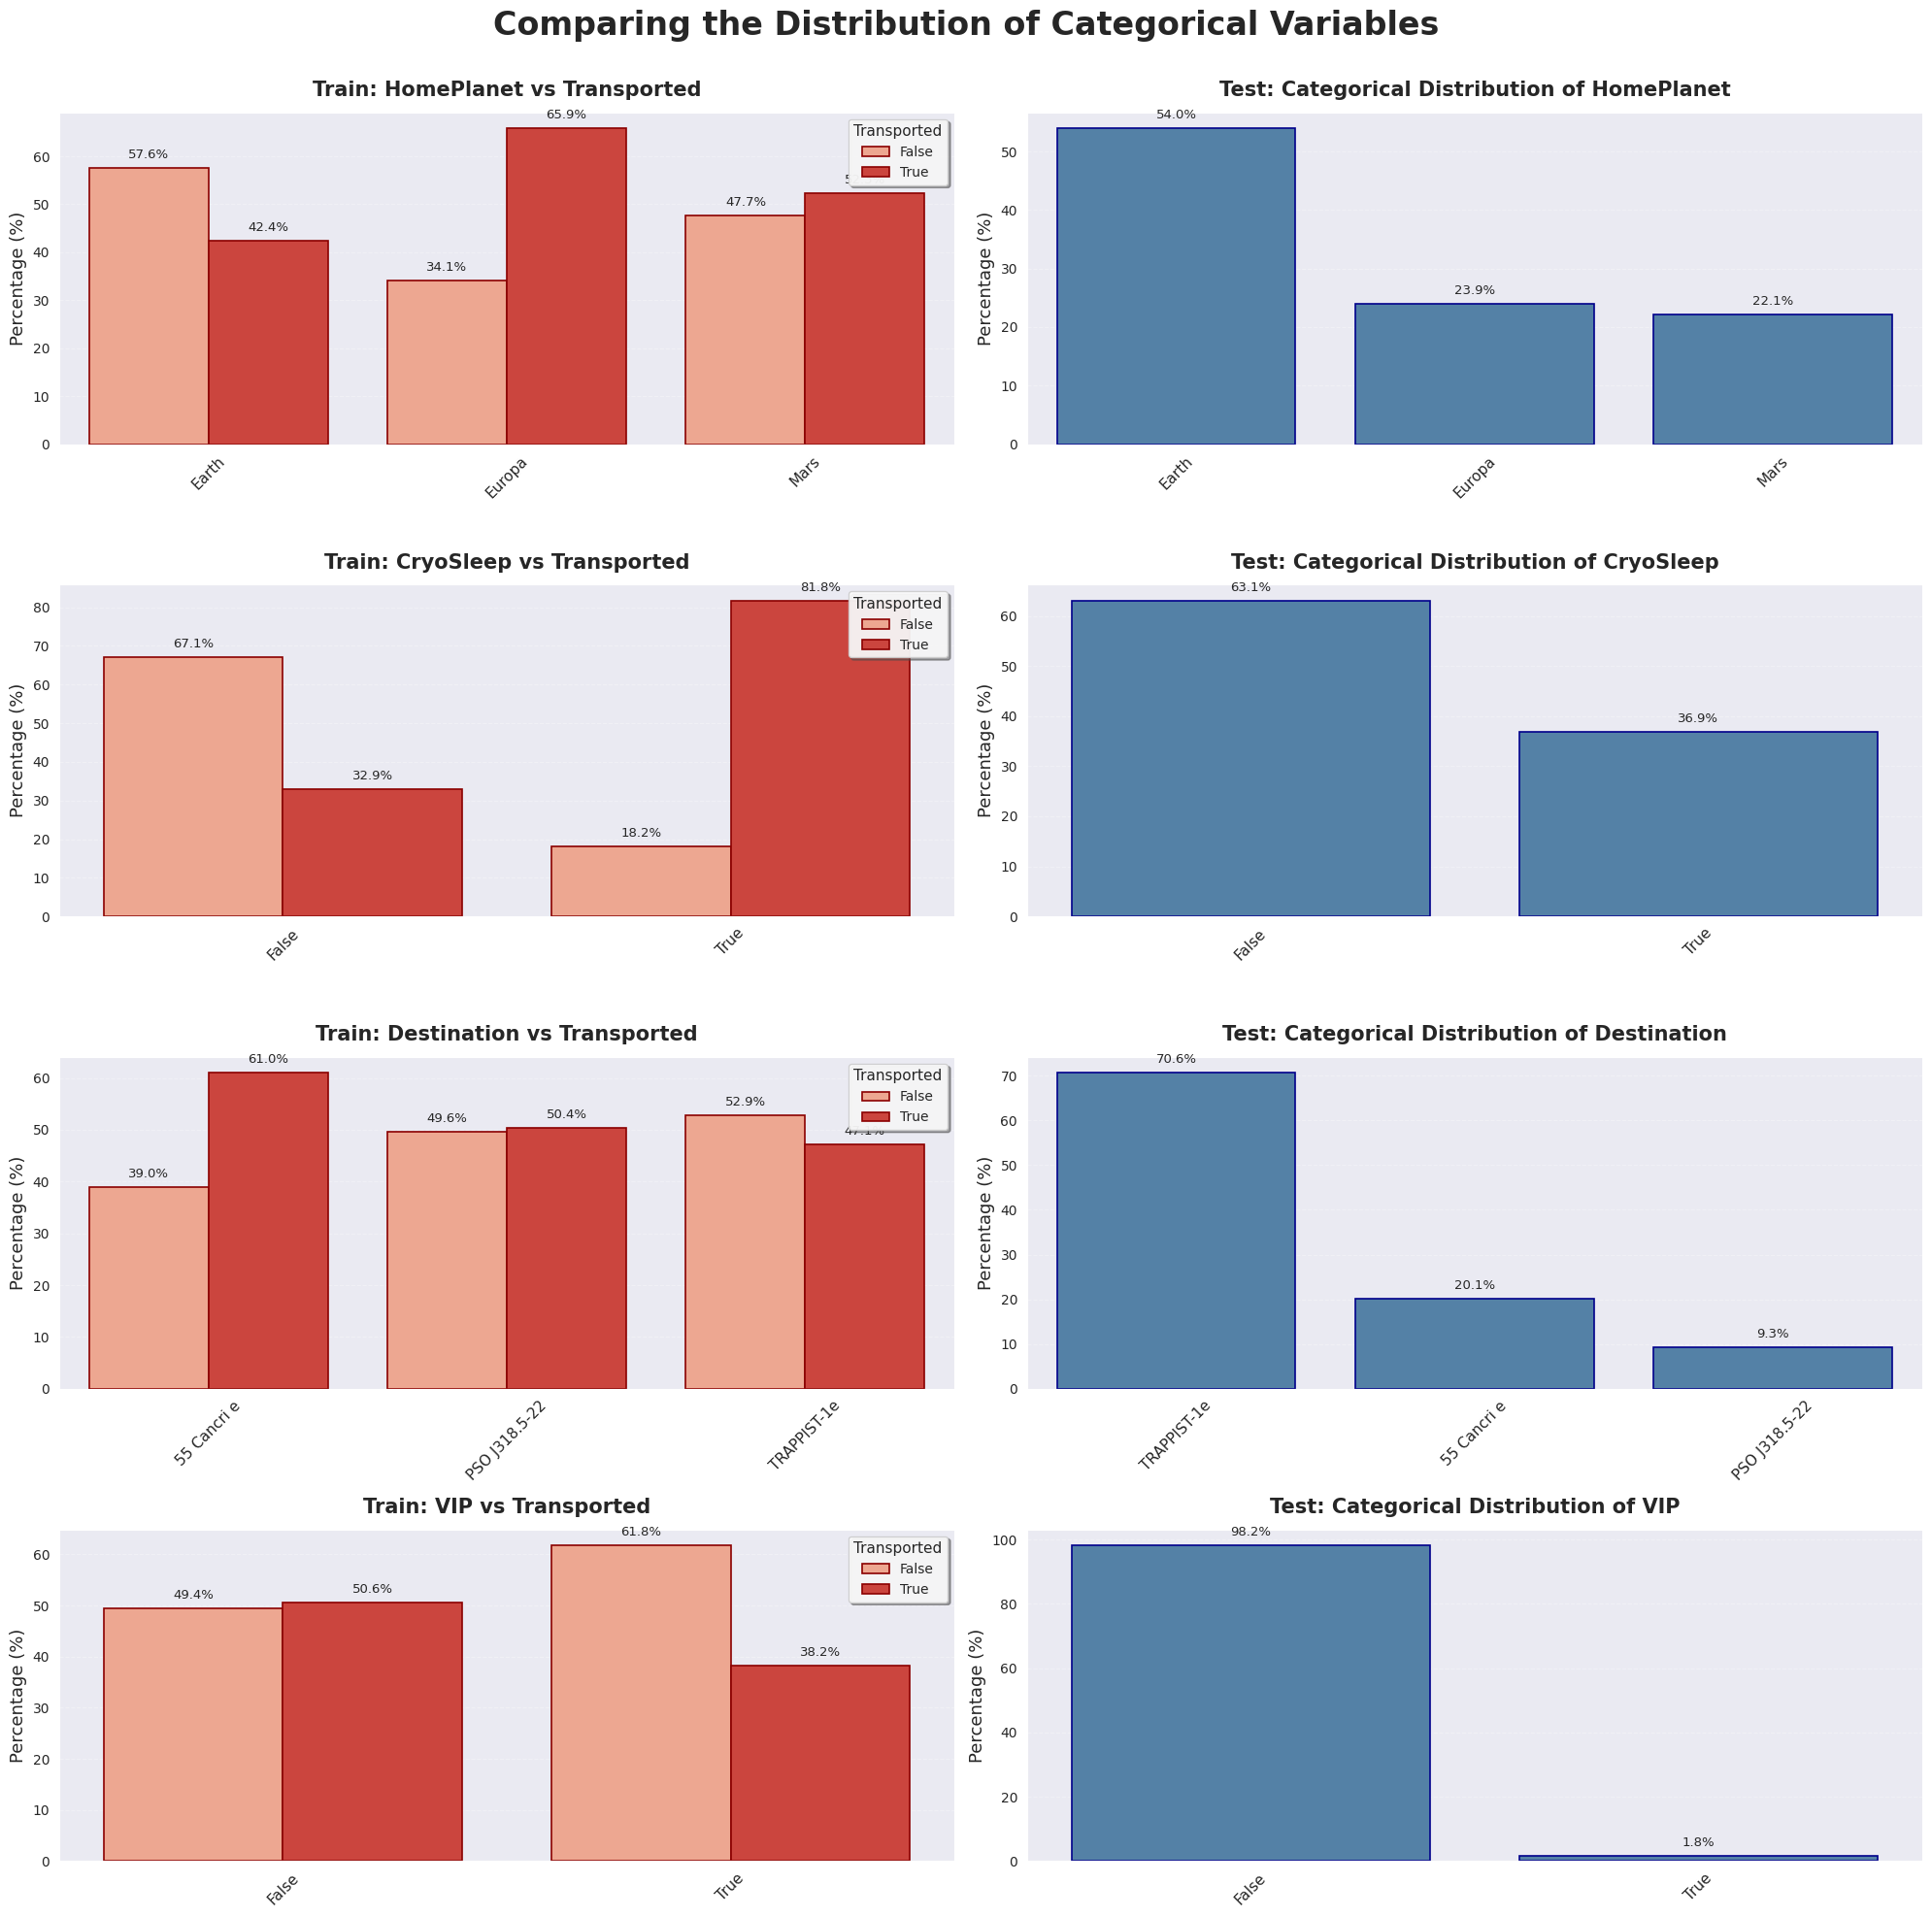

In [13]:
sns.set_style("darkgrid")
 
n_cols = len(cat_cols)
n_rows = n_cols  

fig, axes = plt.subplots(n_rows, 2, figsize=(20, 5*n_rows))  
plt.subplots_adjust(hspace=0.4, wspace=0.25)
 
fig.suptitle('Comparing the Distribution of Categorical Variables', 
             fontsize=24, weight='bold', y=0.995)

for i, col in enumerate(cat_cols):
     
    train_perc = (
        train.groupby(col)['Transported']
        .value_counts(normalize=True)
        .mul(100)
        .reset_index(name='Percentage')
    )
    
     
    sns.barplot(
        x=col, y='Percentage', hue='Transported',
        data=train_perc, ax=axes[i, 0], palette='Reds',
        edgecolor='darkred', linewidth=1.2
    )
    axes[i, 0].set_title(f"Train: {col} vs Transported", 
                         fontsize=15, weight='semibold', pad=12)
    axes[i, 0].set_ylabel('Percentage (%)', fontsize=13, weight='medium')
    axes[i, 0].set_xlabel('')
    axes[i, 0].tick_params(axis='x', rotation=45, labelsize=11)
    axes[i, 0].grid(axis='y', alpha=0.3, linestyle='--')
    
    
    legend = axes[i, 0].legend(title='Transported', 
                               loc='upper right',
                               frameon=True,
                               fancybox=True,
                               shadow=True,
                               fontsize=10,
                               title_fontsize=11)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)
    
   
    for p in axes[i, 0].patches:
        height = p.get_height()
        if height > 0:   
            axes[i, 0].annotate(f'{height:.1f}%',
                               (p.get_x() + p.get_width() / 2., height),
                               ha='center', va='bottom',
                               xytext=(0, 5),
                               textcoords='offset points',
                               fontsize=9.5,
                               weight='medium')
   
  
    test_perc = (
        test[col].value_counts(normalize=True) * 100
    ).reset_index()
    test_perc.columns = [col, 'Percentage']
    
 
    sns.barplot(
        x=col, y='Percentage', data=test_perc,
        ax=axes[i, 1], color='steelblue',
        edgecolor='darkblue', linewidth=1.2
    )
    axes[i, 1].set_title(f"Test: Categorical Distribution of {col}", 
                         fontsize=15, weight='semibold', pad=12)
    axes[i, 1].set_ylabel('Percentage (%)', fontsize=13, weight='medium')
    axes[i, 1].set_xlabel('')
    axes[i, 1].tick_params(axis='x', rotation=45, labelsize=11)
    axes[i, 1].grid(axis='y', alpha=0.3, linestyle='--')
    
 
    for p in axes[i, 1].patches:
        height = p.get_height()
        if height > 0:
            axes[i, 1].annotate(f'{height:.1f}%',
                               (p.get_x() + p.get_width() / 2., height),
                               ha='center', va='bottom',
                               xytext=(0, 5),
                               textcoords='offset points',
                               fontsize=9.5,
                               weight='medium')

plt.tight_layout(rect=[0, 0.01, 1, 0.99])  
plt.show()

 <div style="font-family: 'Segoe UI', Roboto, Arial, sans-serif; line-height: 1.7; color: #e5e7eb; max-width: 900px; background-color: transparent;">
  <div style="border-left: 4px solid #34d399; background-color: rgba(16, 185, 129, 0.08); padding: 1.2rem 1.4rem; border-radius: 10px;">
    <h3 style="color: #6ee7b7; font-weight: 600; margin-top: 0; margin-bottom: 0.8rem; font-size: 1.25rem;">
     -
    </h3>
    <ul style="list-style-type: none; padding-left: 0; color: #d1d5db; margin: 0;">
      <li style="margin-bottom: 1.1rem;">
        <strong style="color: #10b981;">CryoSleep × VIP:</strong><br>
        In this joint analysis, passengers who are both <em>VIP</em> and in <em>CryoSleep</em> show a transport rate of <strong>100%</strong>, confirming that <strong>CryoSleep</strong> is the primary factor influencing transportation outcomes. The <em>VIP</em> status appears to have a secondary effect, slightly enhancing the likelihood when combined with CryoSleep.
      </li>
      <li style="margin-bottom: 1.1rem;">
        <strong style="color: #10b981;">HomePlanet × Destination:</strong><br>
        Passengers departing from <em>Europa</em> and heading to <em>PSO J318.5–22</em> have the highest transport probability of <strong>73.7%</strong>. This suggests that the <strong>origin planet</strong> plays a more crucial role than the destination itself, as Europa consistently shows high transport rates across all destinations.
      </li>
      <li style="margin-bottom: 1.1rem;">
        <strong style="color: #10b981;">Overall Observation:</strong><br>
        When these visualizations are considered together, <strong>CryoSleep</strong> and <strong>HomePlanet</strong> emerge as the dominant features affecting transport likelihood, while <em>VIP</em> and <em>Destination</em> provide secondary explanatory power.
      </li>
    </ul>
  </div>
</div>

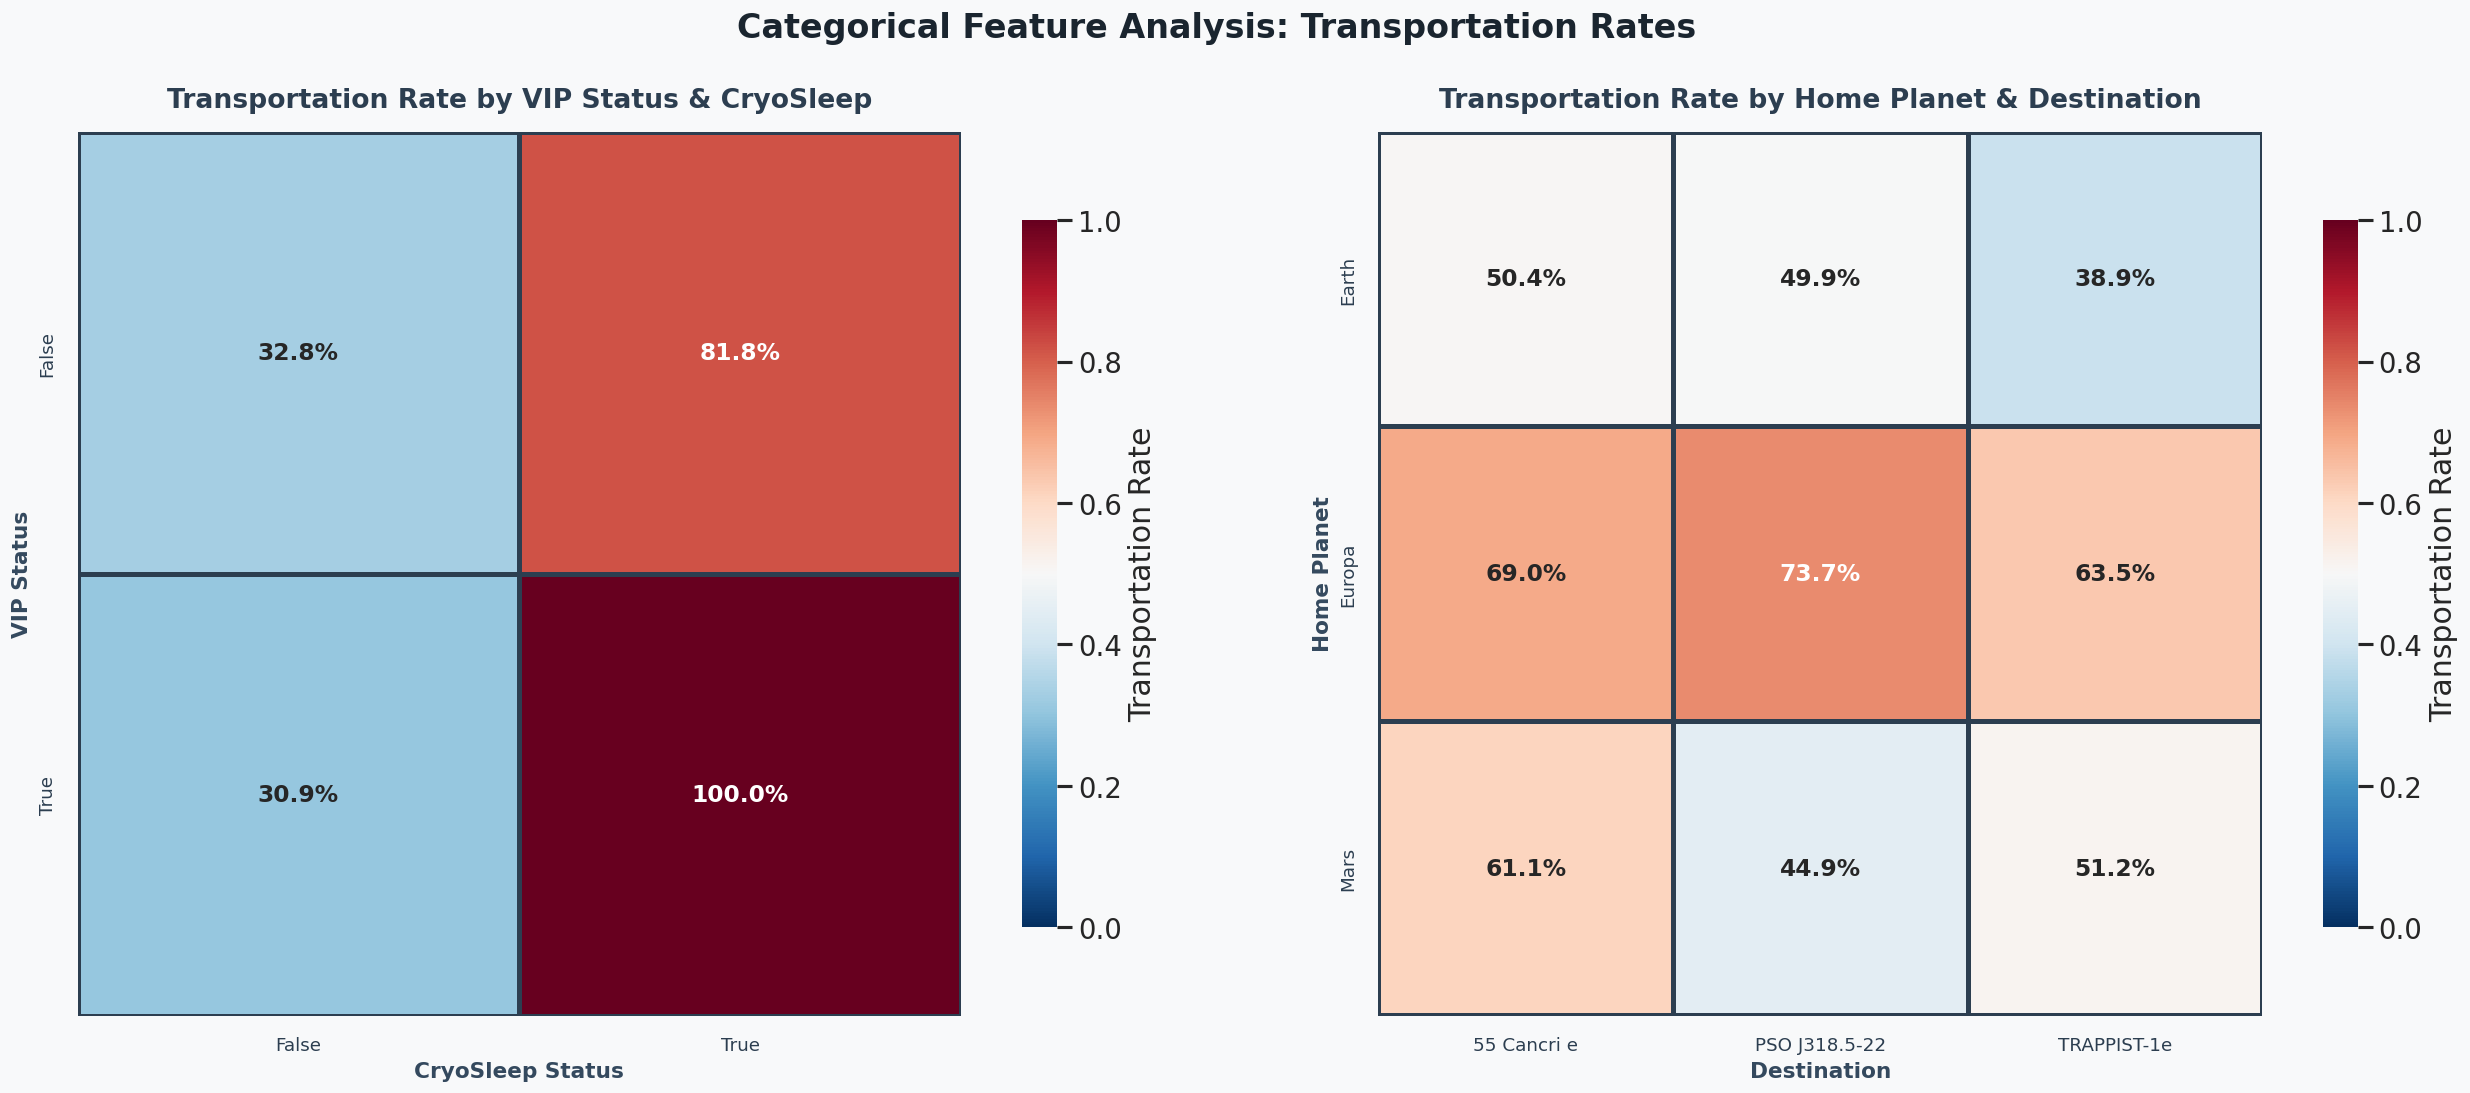

In [14]:
sns.set_theme(style="whitegrid", context="talk")
sns.set_palette("husl")

fig, axes = plt.subplots(1, 2, figsize=(22, 9), dpi=120)
fig.patch.set_facecolor('#f8f9fa')

vip_cryo = train.groupby(['VIP', 'CryoSleep'])['Transported'].mean().reset_index()
vip_cryo_pivot = vip_cryo.pivot(index='VIP', columns='CryoSleep', values='Transported')

sns.heatmap(
    vip_cryo_pivot,
    annot=True,
    fmt=".1%",
    cmap='RdBu_r',
    cbar_kws={'label': 'Transportation Rate', 'shrink': 0.8},
    ax=axes[0],
    linewidths=2,
    linecolor='#2c3e50',
    vmin=0,
    vmax=1,
    square=True,
    annot_kws={'size': 14, 'weight': 'bold'}
)

axes[0].set_title('Transportation Rate by VIP Status & CryoSleep', 
                  fontsize=16, weight='bold', pad=15, color='#2c3e50')
axes[0].set_xlabel('CryoSleep Status', fontsize=13, weight='semibold', color='#34495e')
axes[0].set_ylabel('VIP Status', fontsize=13, weight='semibold', color='#34495e')
axes[0].tick_params(axis='both', labelsize=11, colors='#2c3e50')

ct = pd.crosstab(
    train['HomePlanet'],
    train['Destination'],
    values=train['Transported'],
    aggfunc='mean'
)

sns.heatmap(
    ct,
    annot=True,
    fmt=".1%",
    cmap='RdBu_r',
    cbar_kws={'label': 'Transportation Rate', 'shrink': 0.8},
    ax=axes[1],
    linewidths=2,
    linecolor='#2c3e50',
    vmin=0,
    vmax=1,
    square=True,
    annot_kws={'size': 14, 'weight': 'bold'}
)

axes[1].set_title('Transportation Rate by Home Planet & Destination', 
                  fontsize=16, weight='bold', pad=15, color='#2c3e50')
axes[1].set_xlabel('Destination', fontsize=13, weight='semibold', color='#34495e')
axes[1].set_ylabel('Home Planet', fontsize=13, weight='semibold', color='#34495e')
axes[1].tick_params(axis='both', labelsize=11, colors='#2c3e50')

fig.suptitle('Categorical Feature Analysis: Transportation Rates', 
             fontsize=20, weight='bold', color='#1a252f', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 1.5 Distribution Shape Analysis

In [15]:
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns

skew_kurt_summary = []

for col in numeric_cols:
    skew_kurt_summary.append({
        'Variable': col,
        'Skewness': round(train[col].skew(), 3),
        'Kurtosis': round(train[col].kurt(), 3)
    })

skew_kurt_df = pd.DataFrame(skew_kurt_summary).sort_values(by='Skewness', ascending=False).reset_index(drop=True)
skew_kurt_df

,Variable,Skewness,Kurtosis
0,ShoppingMall,12.628,328.871
1,VRDeck,7.820,86.011
2,Spa,7.636,81.202
3,FoodCourt,7.102,73.307
4,RoomService,6.333,65.274
5,Age,0.419,0.102


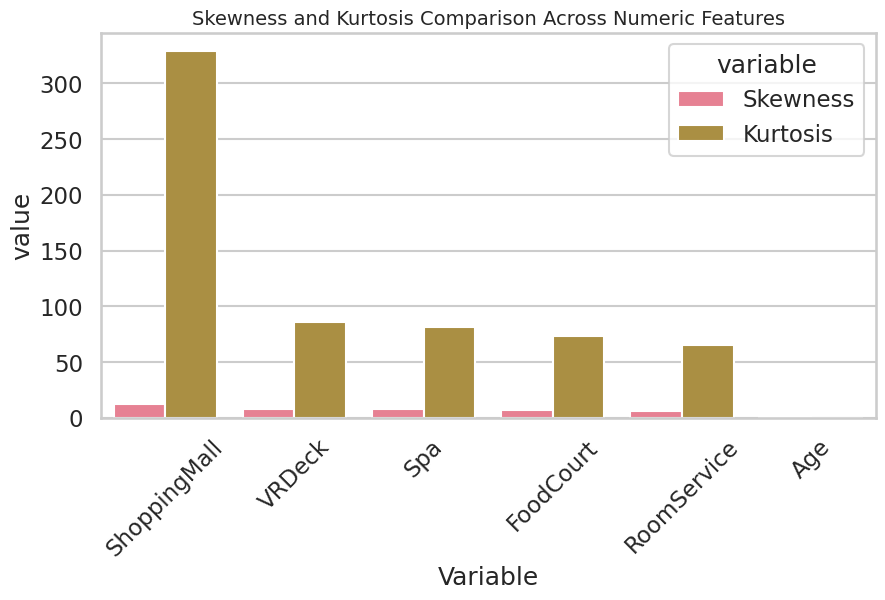

In [16]:
plt.figure(figsize=(10,5))
sns.barplot(data=skew_kurt_df.melt(id_vars='Variable'), x='Variable', y='value', hue='variable')
plt.title("Skewness and Kurtosis Comparison Across Numeric Features", fontsize=14)
plt.xticks(rotation=45)
plt.show()

# 1.6 numerical data analysis

<div style="font-family: 'Segoe UI', Roboto, Arial, sans-serif; line-height: 1.7; color: #f3efff; max-width: 900px; background-color: transparent;">
  <div style="border-left: 4px solid #7c3aed; background-color: rgba(124, 58, 237, 0.08); padding: 1.2rem 1.4rem; border-radius: 10px;">
    <h3 style="color: #c4b5fd; font-weight: 600; margin-top: 0; margin-bottom: 0.8rem; font-size: 1.25rem;">
      Age and Spending Behavior Analysis
    </h3>
    <ul style="list-style-type: none; padding-left: 0; color: #e6e1ff; margin: 0;">
      <li style="margin-bottom: 1.1rem;">
        I analyzed the <strong>Age</strong> variable separately to better understand its distribution and relationship with the target variable. On the left, the KDE plots of both the train and test sets show that the distributions are highly similar, indicating consistent sampling between datasets. On the right, the KDE plot of the training data demonstrates the relationship between age and the probability of being <strong>Transported</strong>. As seen in the plot, transportation is most common between the ages of <strong>20 and 40</strong>, represented by the blue KDE curve (which indicates transported passengers).
      </li>
      <li style="margin-bottom: 1.1rem;">
        Interestingly, there is an unusual increase in transportation probability among passengers aged <strong>0–10</strong>. This led me to think about possible interactions with other features. Since <strong>CryoSleep</strong> has shown the strongest relationship with the target variable so far, and <strong>HomePlanet</strong> also appears to have a strong influence, I suspect that the 0–10 age group might be more likely to be from <em>Europa</em> or more likely to be in <em>CryoSleep</em>, which could explain this unexpected pattern.
      </li>
      <li style="margin-bottom: 1.1rem;">
        Regarding the <strong>spending variables</strong> (<em>RoomService, FoodCourt, ShoppingMall, Spa, VRDeck</em>), both the train and test datasets display <strong>long-tailed distributions</strong>. A small number of passengers have extremely high spending values, while many have zero expenditures. This suggests that the data are far from normally distributed, making <strong>normalization or standardization</strong> an essential step — and one that should be carefully planned.
      </li>
      <li style="margin-bottom: 1.1rem;">
        In the <strong>outlier analysis</strong>, the spending features show roughly <strong>20% of values as outliers</strong>. This raises an important question: Are these outliers caused by the same group of passengers across all spending categories, or are they independent cases? For instance, are the people spending heavily on <em>VRDeck</em> also the same ones spending heavily on <em>Spa</em>? Understanding this pattern will help determine whether the outliers represent unique individual behaviors or a specific passenger segment.
      </li>
      <li>
        Lastly, the <strong>Age</strong> variable contains very few outliers, which is a positive sign. The <strong>box and violin plots</strong> clearly visualize both the concentration and the spread of outliers across all variables, confirming the skewness and the variability patterns discussed above.
      </li>
    </ul>
  </div>
</div>

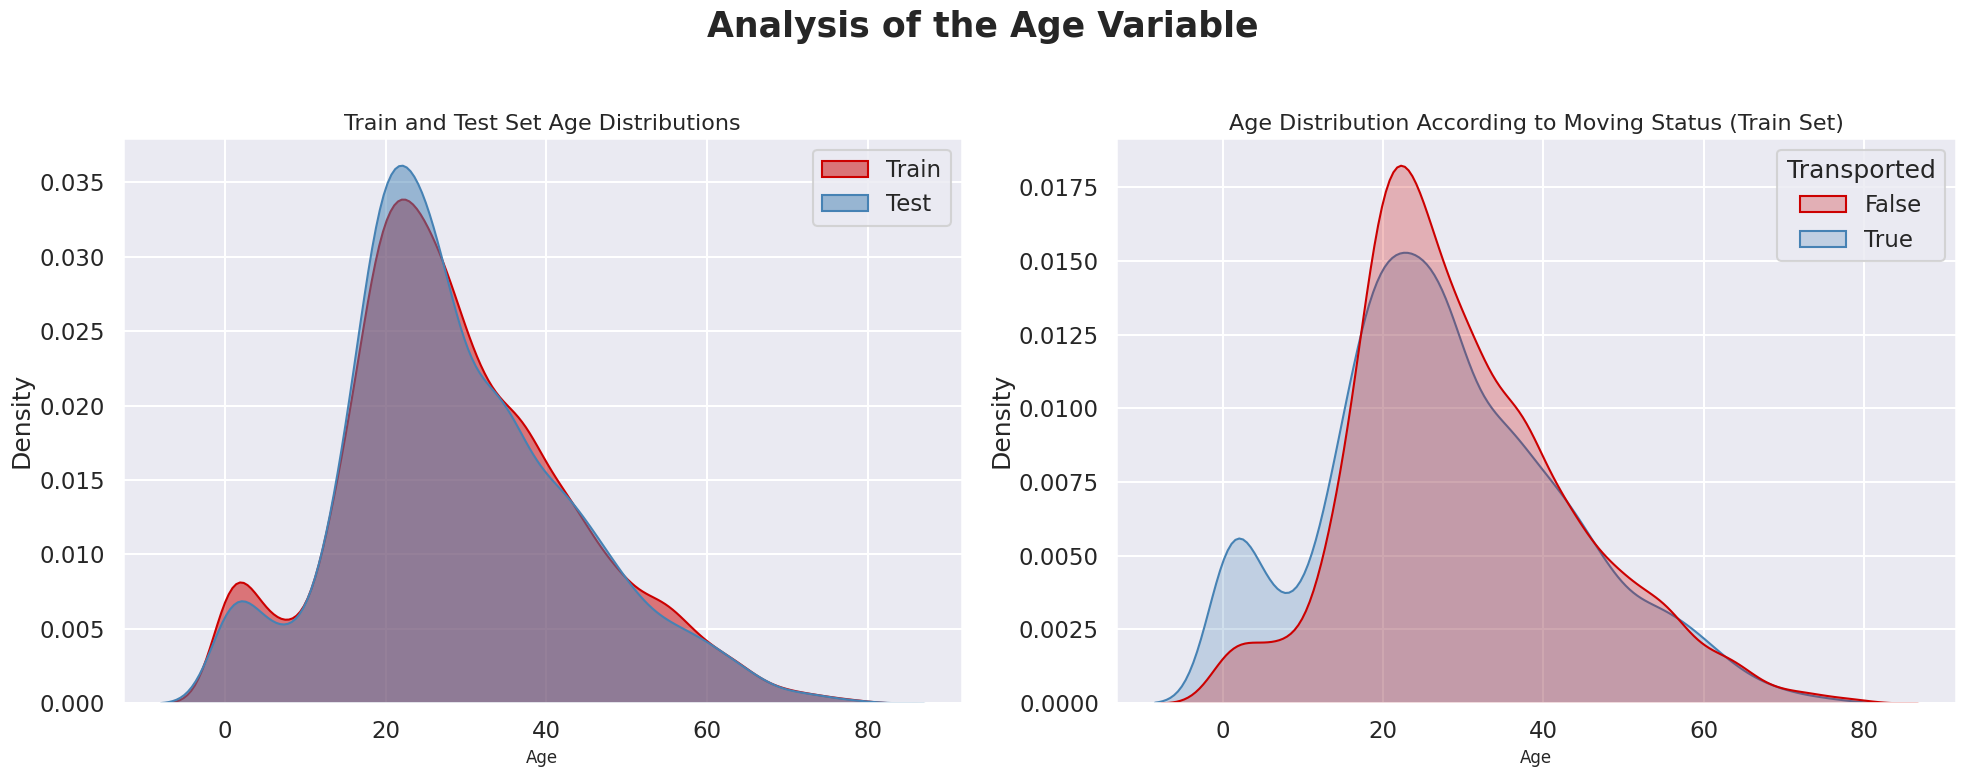

In [17]:
sns.set_style("darkgrid")
 
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Analysis of the Age Variable', fontsize=25, weight='bold')

 
sns.kdeplot(data=train, x='Age', label='Train', ax=axes[0], color='#cc0000', fill=True, alpha=0.5)
sns.kdeplot(data=test, x='Age', label='Test', ax=axes[0], color='steelblue', fill=True, alpha=0.5)
axes[0].set_title('Train and Test Set Age Distributions', fontsize=16)
axes[0].set_xlabel('Age', fontsize=12)
axes[0].legend()

custom_palette = {False: "#cc0000", True: "steelblue"}

sns.kdeplot(data=train, x='Age', hue='Transported', ax=axes[1], fill=True, palette=custom_palette)
axes[1].set_title('Age Distribution According to Moving Status (Train Set)', fontsize=16)
axes[1].set_xlabel('Age', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

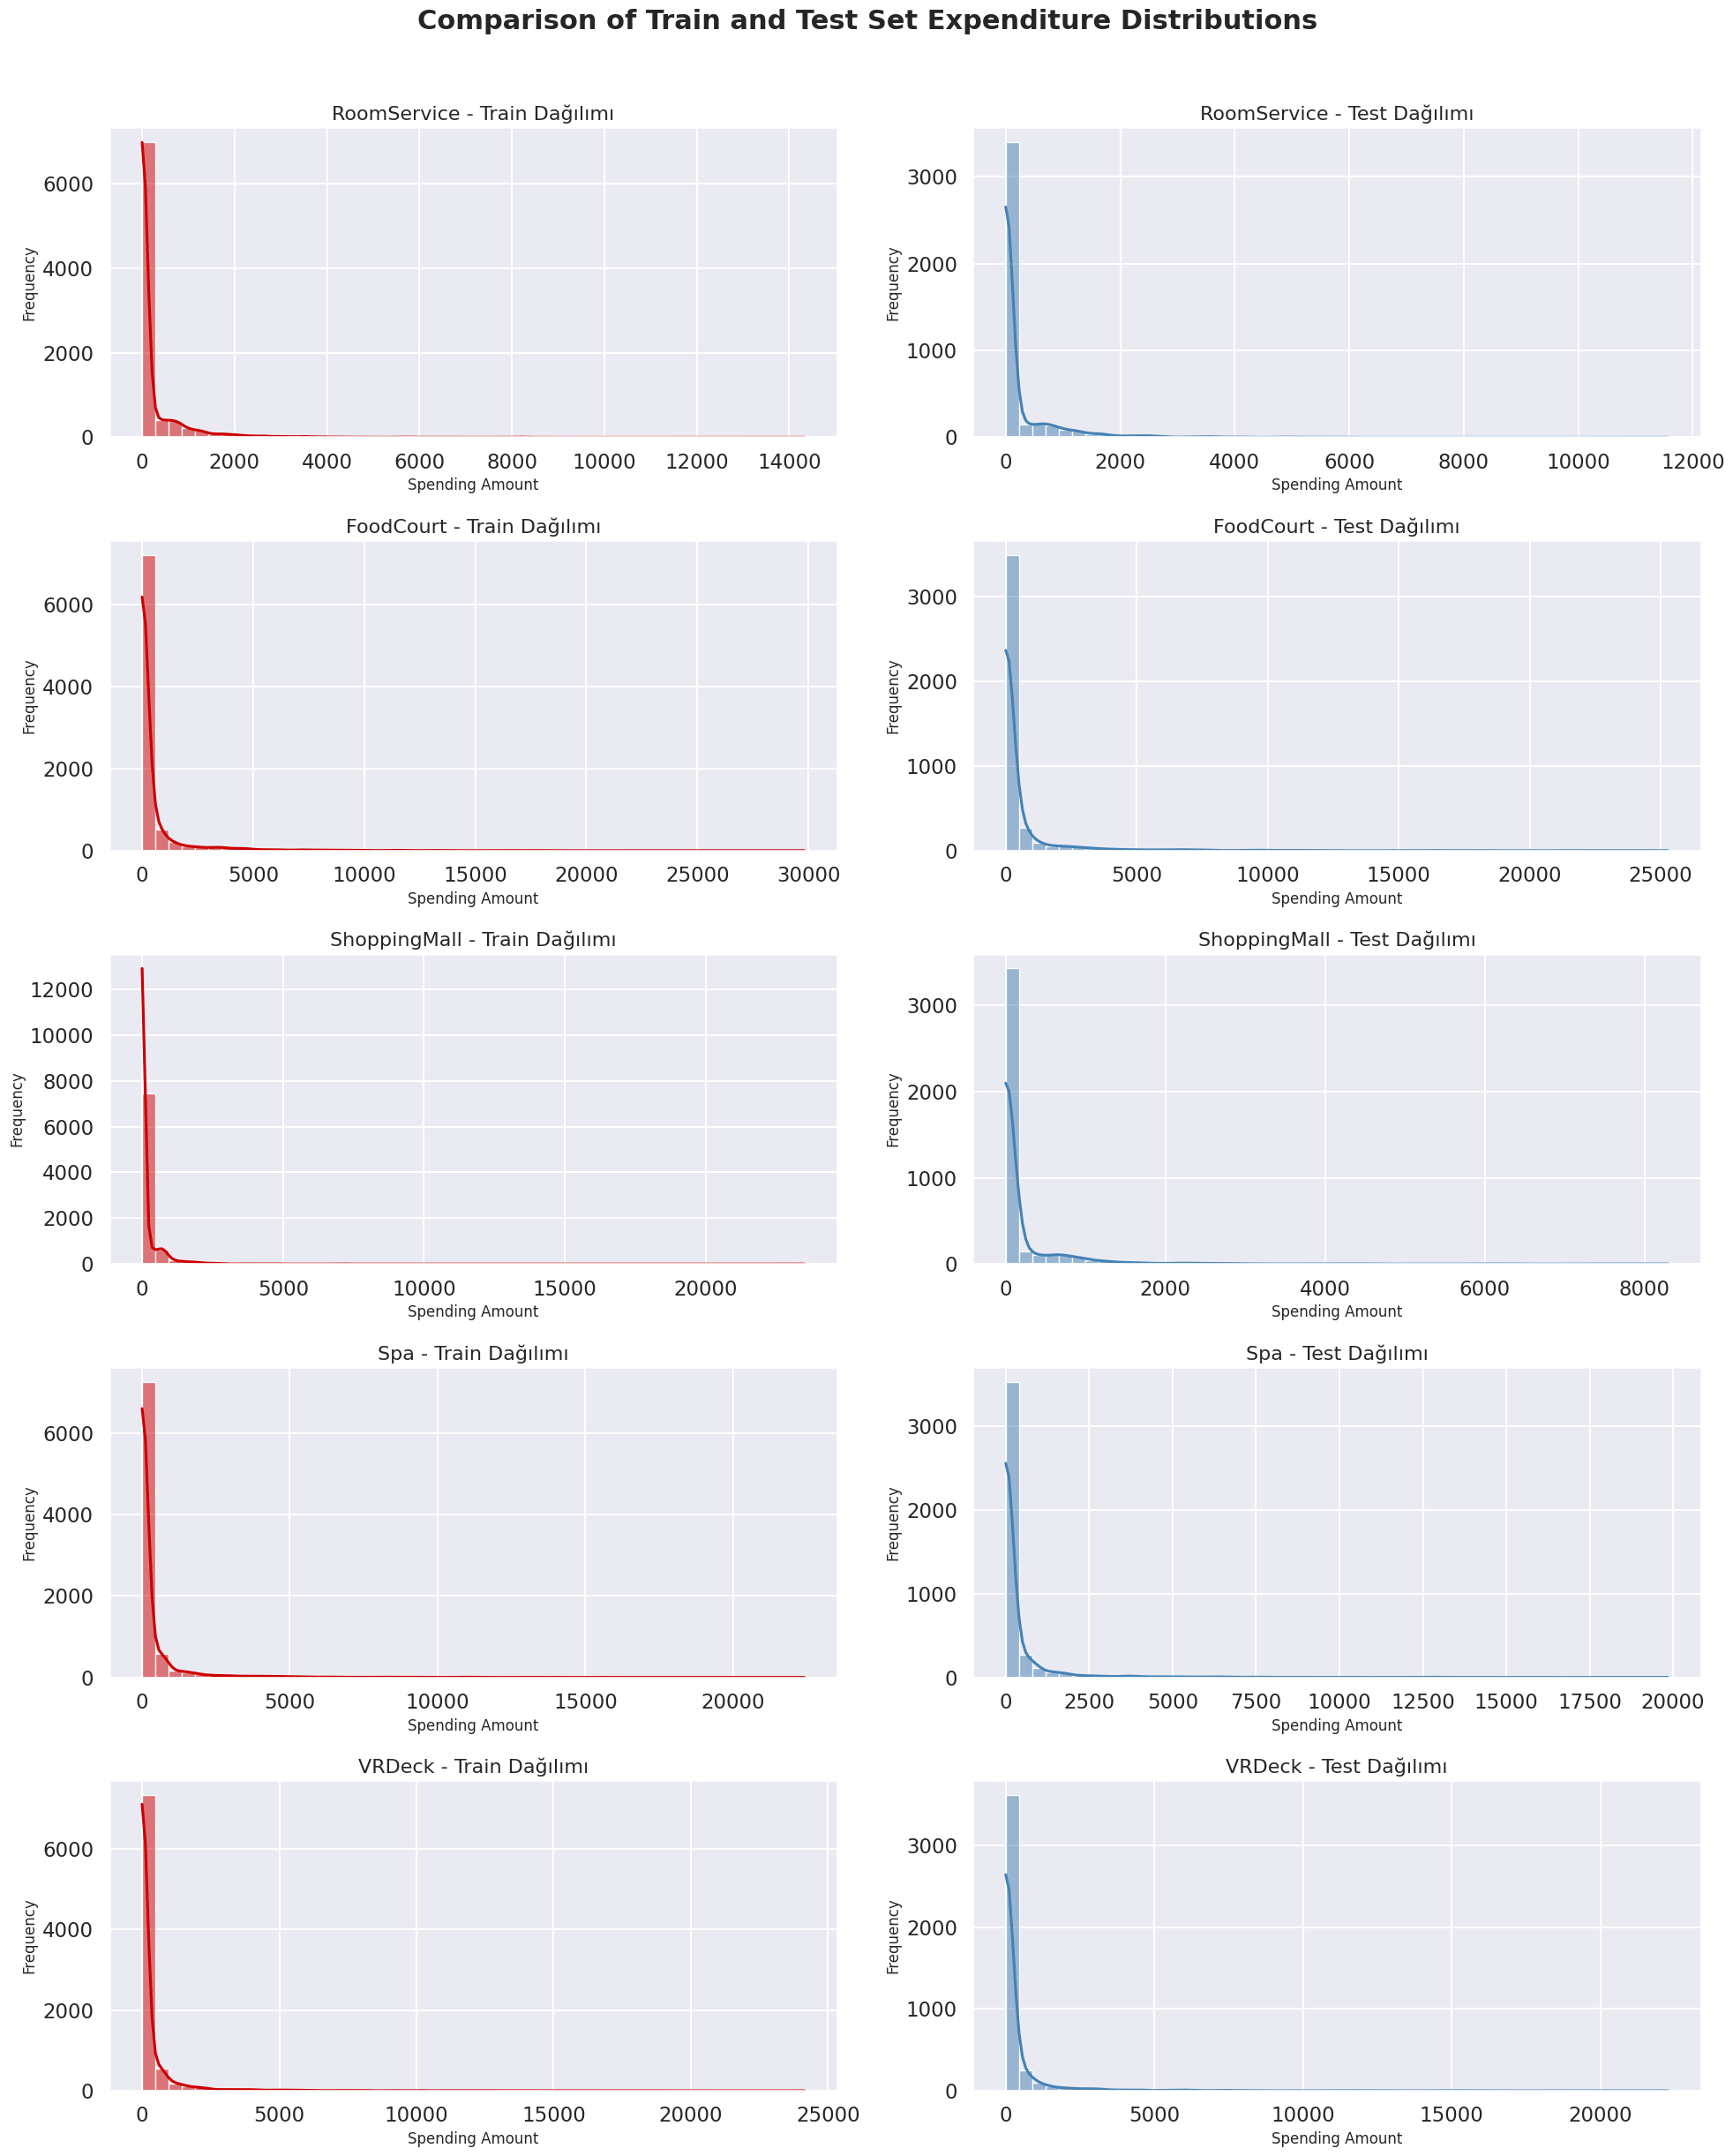

In [18]:
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
 
sns.set_style("darkgrid")
 
fig, axes = plt.subplots(len(spending_cols), 2, figsize=(20, 25))
fig.suptitle('Comparison of Train and Test Set Expenditure Distributions', fontsize=22, weight='bold')

for i, col in enumerate(spending_cols):
   
    sns.histplot(data=train, x=col, ax=axes[i, 0], color='#cc0000', kde=True, bins=50)
    axes[i, 0].set_title(f'{col} - Train Dağılımı', fontsize=16)
    axes[i, 0].set_xlabel('Spending Amount', fontsize=12)
    axes[i, 0].set_ylabel('Frequency', fontsize=12)
 
    sns.histplot(data=test, x=col, ax=axes[i, 1], color='steelblue', kde=True, bins=50)
    axes[i, 1].set_title(f'{col} - Test Dağılımı', fontsize=16)
    axes[i, 1].set_xlabel('Spending Amount', fontsize=12)
    axes[i, 1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# 1.7 Outlier Analysis

In [19]:
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
 
outlier_summary = []
 
for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = train[(train[col] < lower) | (train[col] > upper)][col]
    
    outlier_summary.append({
        'Variable': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count': len(outliers),
        'Outlier Ratio (%)': round(100 * len(outliers) / len(train), 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df 

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Ratio (%)
0,Age,19.0,38.0,19.0,-9.5,66.5,77,0.89
1,RoomService,0.0,47.0,47.0,-70.5,117.5,1861,21.41
2,FoodCourt,0.0,76.0,76.0,-114.0,190.0,1823,20.97
3,ShoppingMall,0.0,27.0,27.0,-40.5,67.5,1829,21.04
4,Spa,0.0,59.0,59.0,-88.5,147.5,1788,20.57
5,VRDeck,0.0,46.0,46.0,-69.0,115.0,1809,20.81


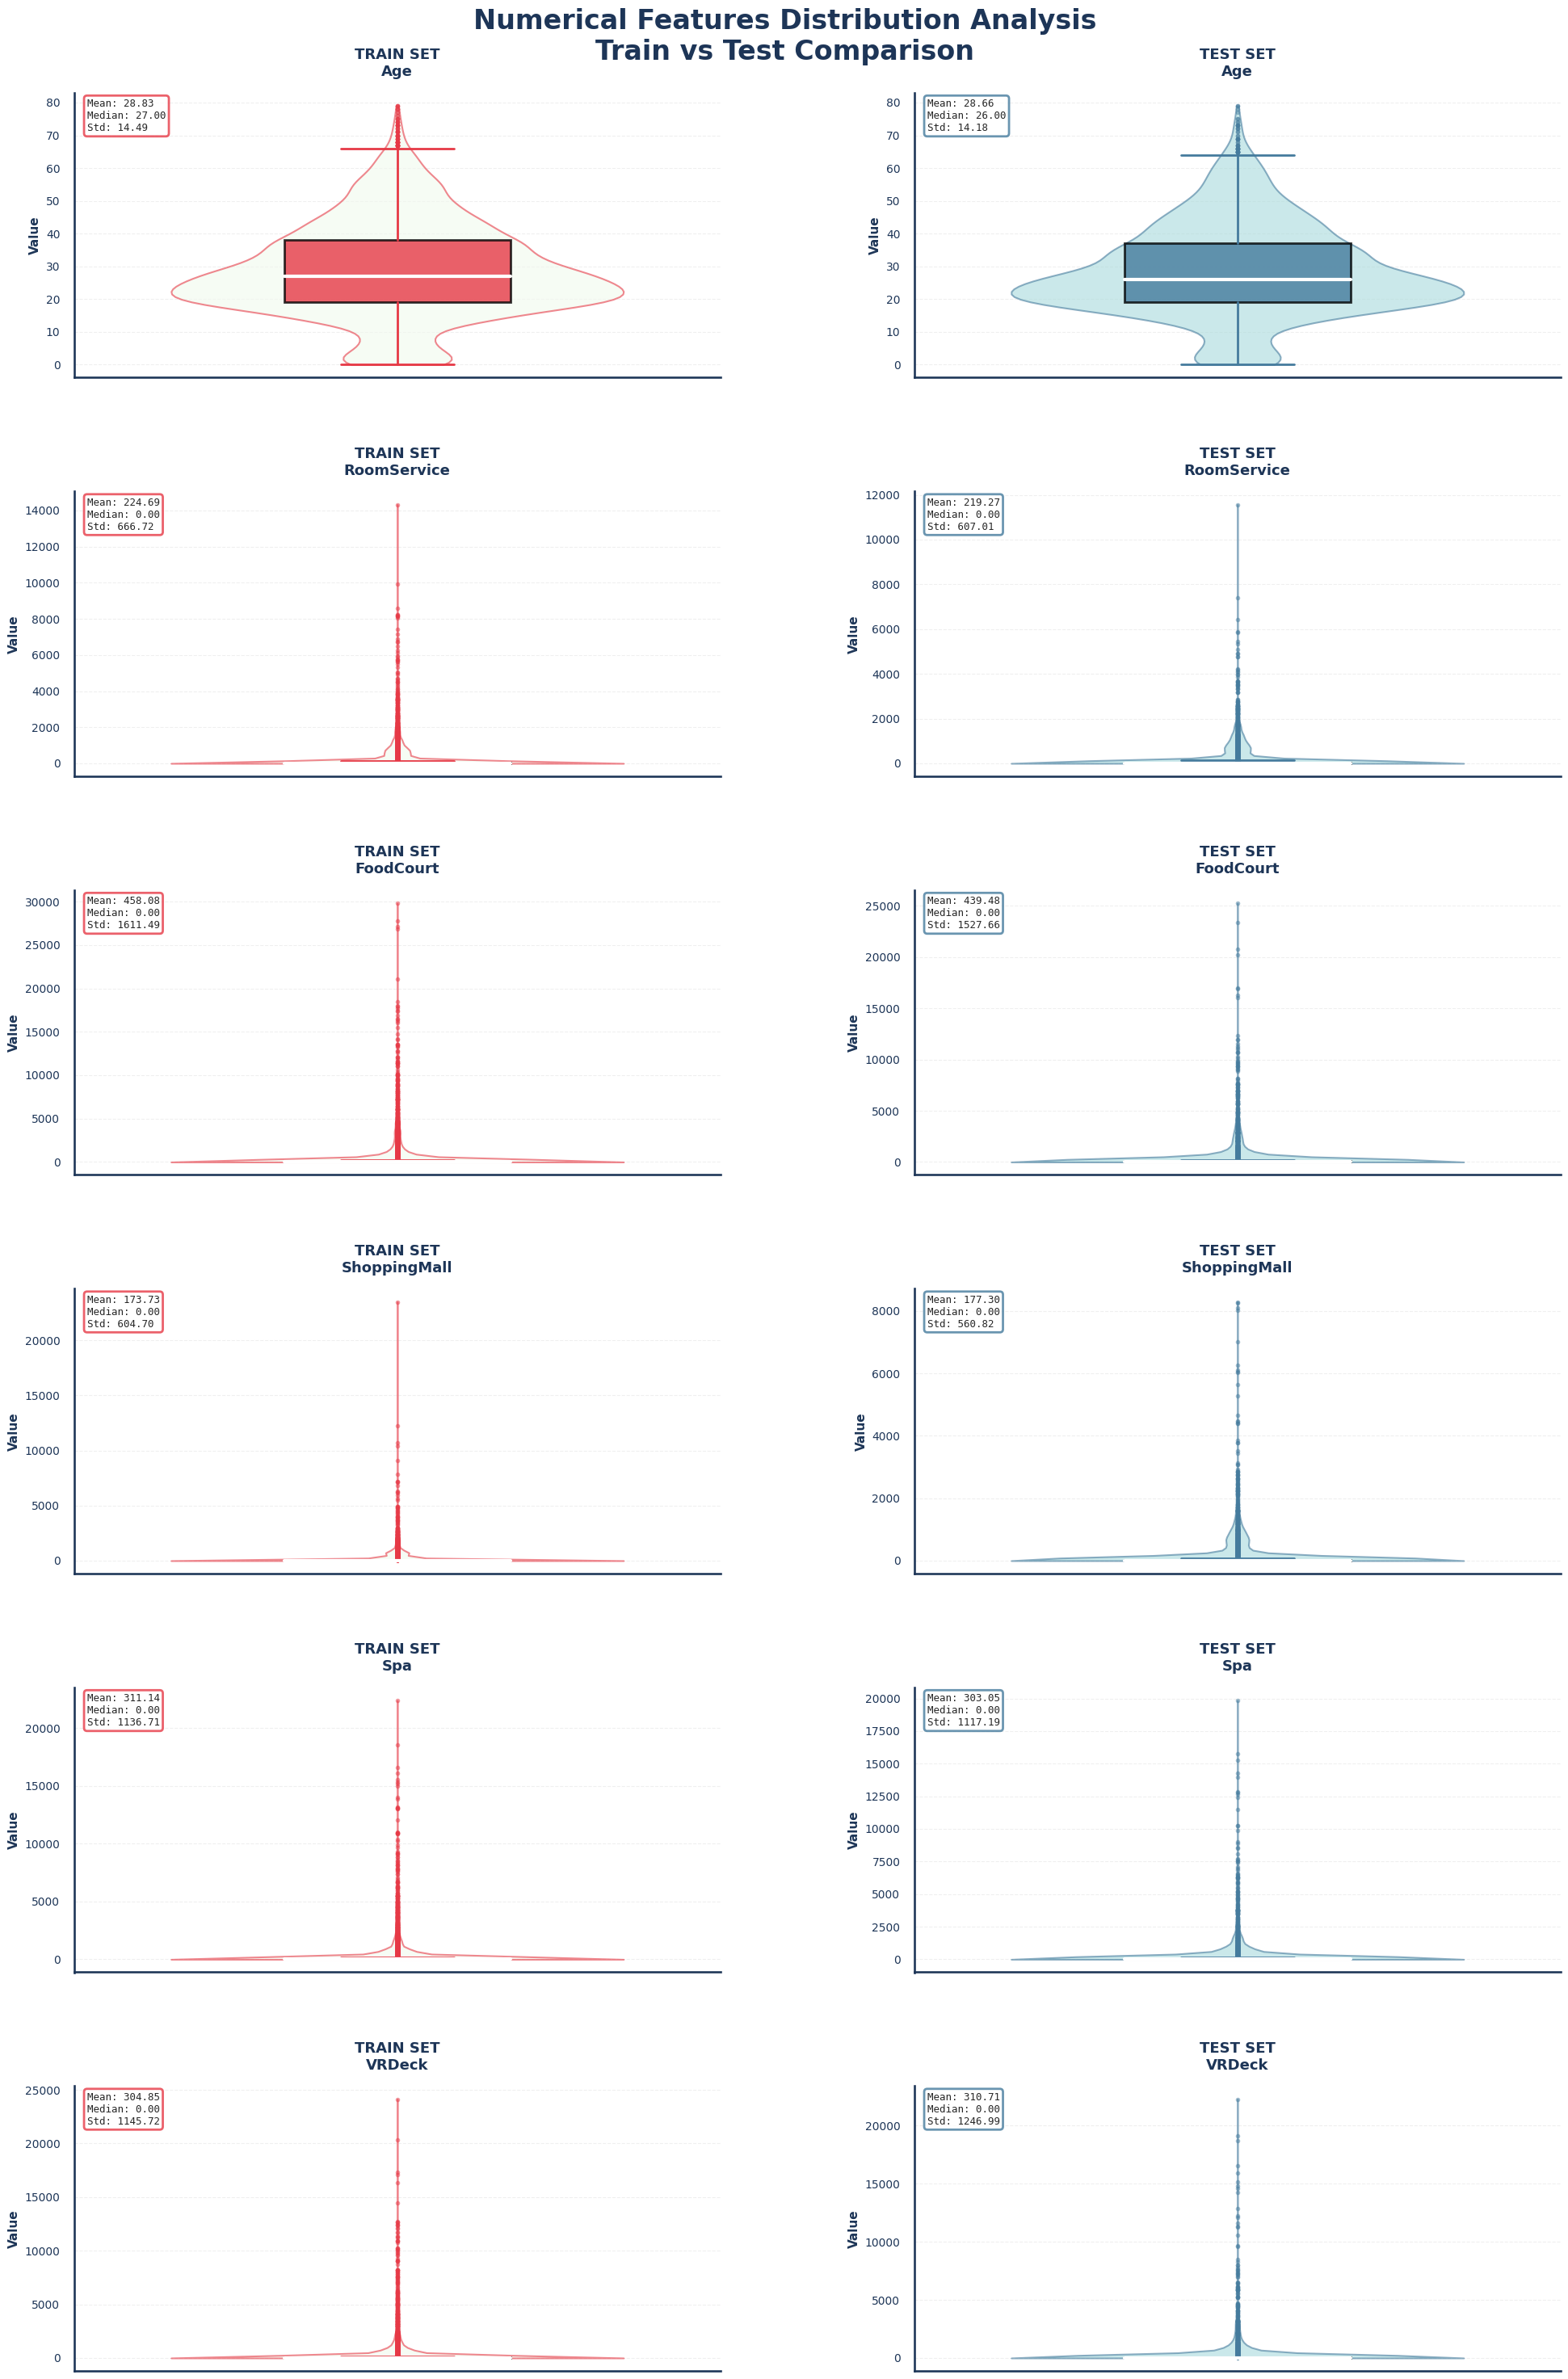

In [20]:
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

 
train_color = '#E63946'   
test_color = '#457B9D'    
train_violin = '#F1FAEE'  
test_violin = '#A8DADC'   
 
fig, axes = plt.subplots(len(num_cols), 2, figsize=(20, 5*len(num_cols)))
 
fig.suptitle('Numerical Features Distribution Analysis\nTrain vs Test Comparison', 
             fontsize=24, weight='bold', y=0.995, 
             fontfamily='sans-serif', color='#1D3557')
 
if len(num_cols) == 1:
    axes = axes.reshape(1, -1)

for i, col in enumerate(num_cols):
 
    ax_train = axes[i, 0]
  
    parts_train = ax_train.violinplot([train[col].dropna()], positions=[0], 
                                       widths=0.7, showmeans=False, 
                                       showmedians=False, showextrema=False)
    for pc in parts_train['bodies']:
        pc.set_facecolor(train_violin)
        pc.set_alpha(0.6)
        pc.set_edgecolor(train_color)
        pc.set_linewidth(1.5)
   
    bp_train = ax_train.boxplot([train[col].dropna()], positions=[0], 
                                  widths=0.35, patch_artist=True,
                                  boxprops=dict(facecolor=train_color, alpha=0.8, linewidth=2),
                                  whiskerprops=dict(color=train_color, linewidth=2),
                                  capprops=dict(color=train_color, linewidth=2),
                                  medianprops=dict(color='white', linewidth=3),
                                  flierprops=dict(marker='o', markerfacecolor=train_color, 
                                                 markersize=4, alpha=0.5, markeredgecolor='none'))
    
    ax_train.set_title(f'TRAIN SET\n{col}', fontsize=13, weight='bold', 
                       pad=15, color='#1D3557', fontfamily='sans-serif')
    ax_train.set_ylabel('Value', fontsize=11, weight='bold', color='#1D3557')
    ax_train.set_xticks([])
    ax_train.spines['top'].set_visible(False)
    ax_train.spines['right'].set_visible(False)
    ax_train.spines['left'].set_color('#1D3557')
    ax_train.spines['bottom'].set_color('#1D3557')
    ax_train.tick_params(colors='#1D3557', labelsize=10)
    ax_train.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
  
    train_stats = train[col].describe()
    stats_text_train = f"Mean: {train_stats['mean']:.2f}\nMedian: {train_stats['50%']:.2f}\nStd: {train_stats['std']:.2f}"
    ax_train.text(0.02, 0.98, stats_text_train, transform=ax_train.transAxes,
                  fontsize=9, verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=train_color, linewidth=2),
                  fontfamily='monospace')
  
    ax_test = axes[i, 1]
 
    parts_test = ax_test.violinplot([test[col].dropna()], positions=[0], 
                                     widths=0.7, showmeans=False, 
                                     showmedians=False, showextrema=False)
    for pc in parts_test['bodies']:
        pc.set_facecolor(test_violin)
        pc.set_alpha(0.6)
        pc.set_edgecolor(test_color)
        pc.set_linewidth(1.5)
    
    
    bp_test = ax_test.boxplot([test[col].dropna()], positions=[0], 
                                widths=0.35, patch_artist=True,
                                boxprops=dict(facecolor=test_color, alpha=0.8, linewidth=2),
                                whiskerprops=dict(color=test_color, linewidth=2),
                                capprops=dict(color=test_color, linewidth=2),
                                medianprops=dict(color='white', linewidth=3),
                                flierprops=dict(marker='o', markerfacecolor=test_color, 
                                               markersize=4, alpha=0.5, markeredgecolor='none'))
    
    ax_test.set_title(f'TEST SET\n{col}', fontsize=13, weight='bold', 
                      pad=15, color='#1D3557', fontfamily='sans-serif')
    ax_test.set_ylabel('Value', fontsize=11, weight='bold', color='#1D3557')
    ax_test.set_xticks([])
    ax_test.spines['top'].set_visible(False)
    ax_test.spines['right'].set_visible(False)
    ax_test.spines['left'].set_color('#1D3557')
    ax_test.spines['bottom'].set_color('#1D3557')
    ax_test.tick_params(colors='#1D3557', labelsize=10)
    ax_test.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
    
    test_stats = test[col].describe()
    stats_text_test = f"Mean: {test_stats['mean']:.2f}\nMedian: {test_stats['50%']:.2f}\nStd: {test_stats['std']:.2f}"
    ax_test.text(0.02, 0.98, stats_text_test, transform=ax_test.transAxes,
                 fontsize=9, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=test_color, linewidth=2),
                 fontfamily='monospace')
 
plt.subplots_adjust(hspace=0.4, wspace=0.3, top=0.96, bottom=0.02, left=0.06, right=0.98)
plt.show()

# 1.8 Feature Relationships Analysis

<div style="font-family: 'Segoe UI', Roboto, Arial, sans-serif; line-height: 1.7; color: #e5e7eb; max-width: 900px; background-color: transparent;">
  <div style="border-left: 4px solid #ef4444; background-color: rgba(239, 68, 68, 0.08); padding: 1.2rem 1.4rem; border-radius: 10px;">
    <h3 style="color: #f87171; font-weight: 600; margin-top: 0; margin-bottom: 0.8rem; font-size: 1.25rem;">
      Spending Features Analysis (Pairplot)
    </h3>
    <p style="color: #d1d5db; margin-bottom: 1rem;">
      The most notable observation from the pairplots involves the spending features: <strong>RoomService</strong>, <strong>Spa</strong>, and <strong>VRDeck</strong>. Passengers who spent money on these services (values greater than 0) predominantly belong to the <strong>Transported=False</strong> group. In contrast, transported passengers (<strong>Transported=True</strong>) have almost no spending in these categories, with values concentrated at zero. This pattern indicates that higher luxury or entertainment expenditures are a strong predictor of not being transported.
    </p>
  </div>
</div>


<Figure size 1000x1000 with 0 Axes>

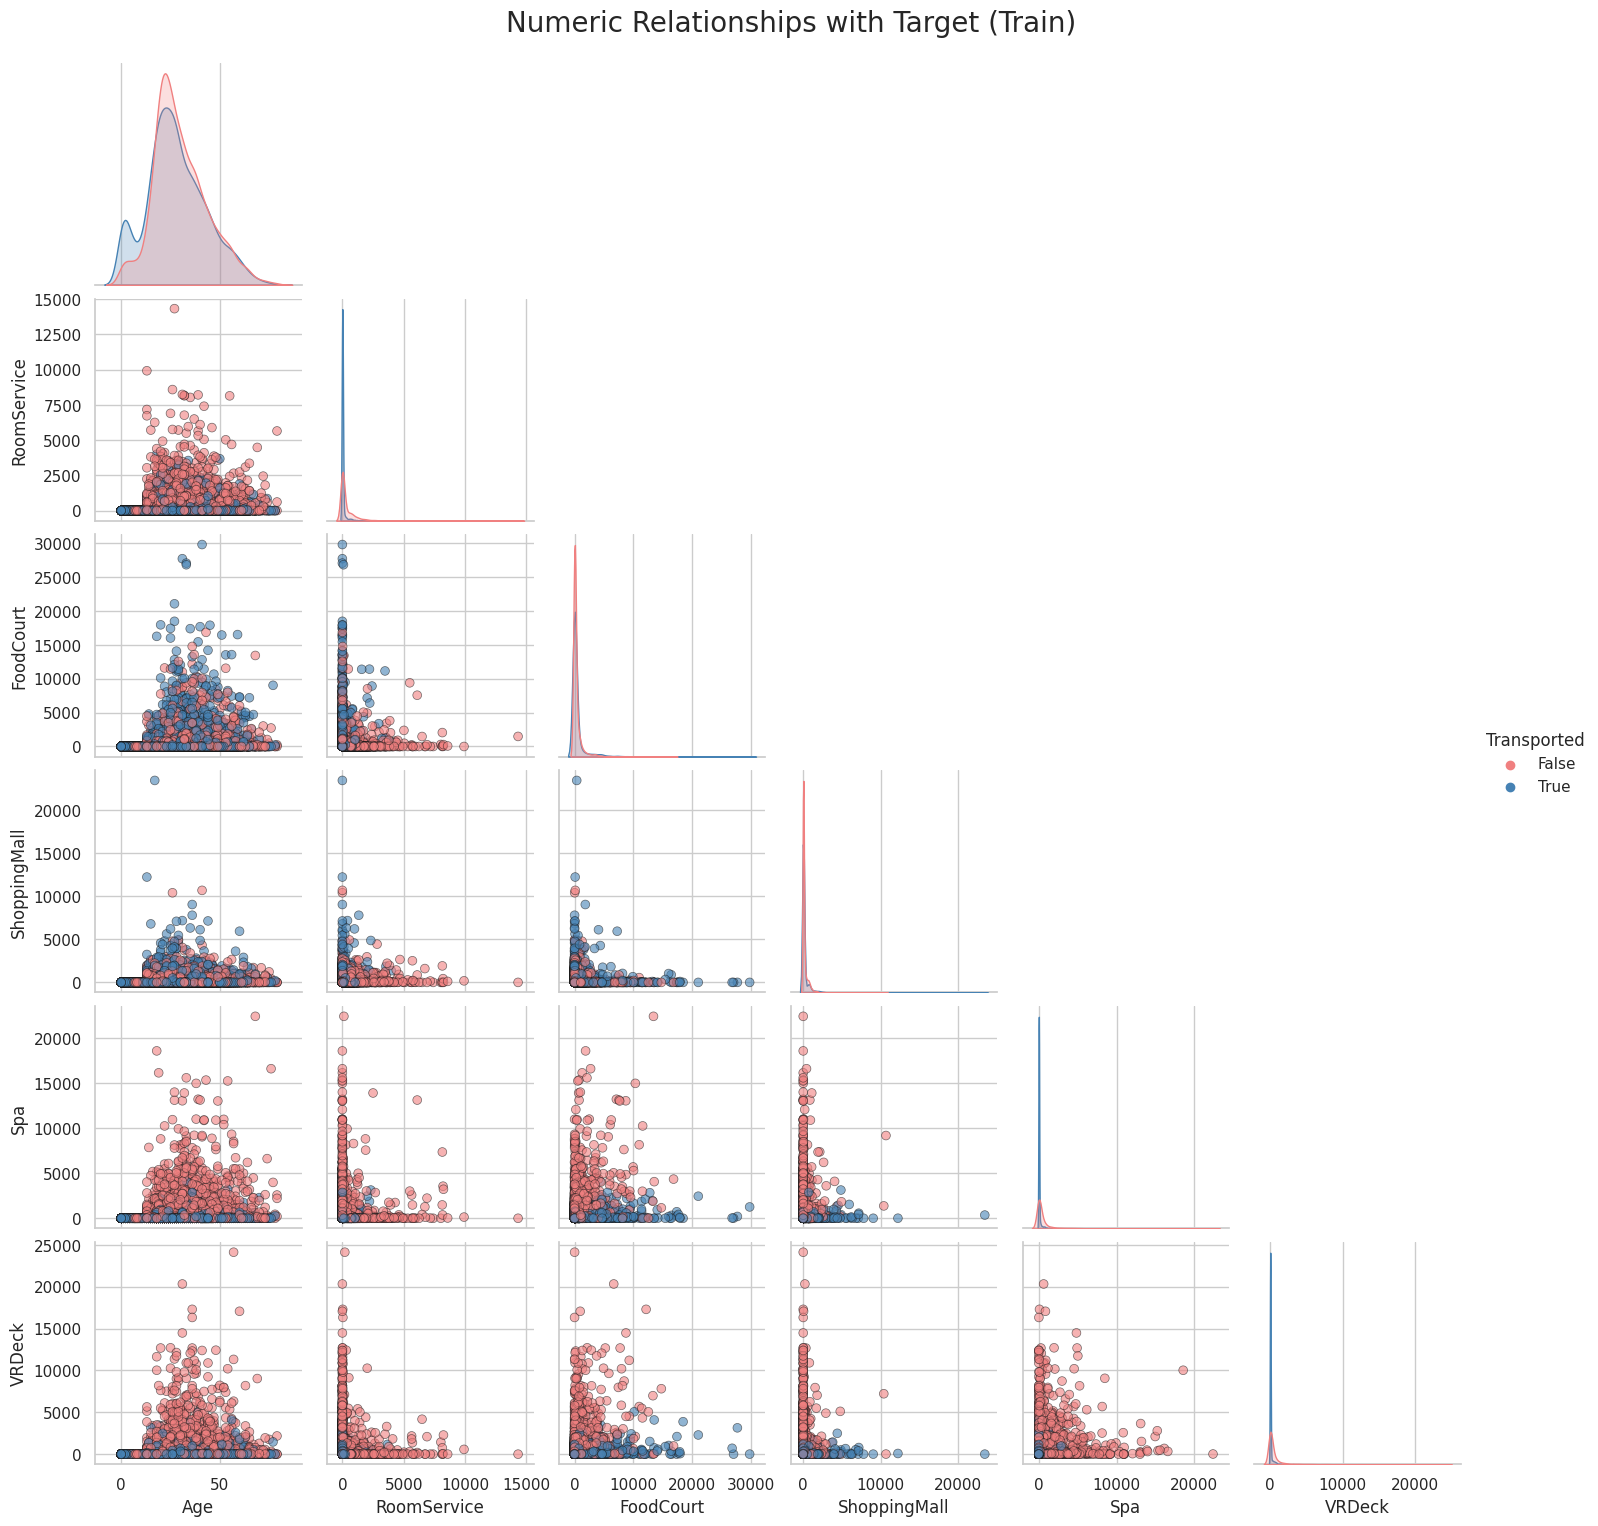

In [21]:
sns.set(style='whitegrid')

plt.figure(figsize=(10,10))
sns.pairplot(
    train[num_cols + ['Transported']],   
    corner=True,
    diag_kind='kde',
    hue='Transported',                   
    palette={True:'steelblue', False:'lightcoral'},
    plot_kws={'alpha':0.6, 's':40, 'edgecolor':'k'}
)

plt.suptitle('Numeric Relationships with Target (Train)', fontsize=20, y=1.02)
plt.show()

<div style="font-family: 'Segoe UI', Roboto, Arial, sans-serif; line-height: 1.7; color: #e5e7eb; max-width: 900px; background-color: transparent;">
  <div style="border-left: 4px solid #3b82f6; background-color: rgba(59, 130, 246, 0.08); padding: 1.2rem 1.4rem; border-radius: 10px;">
    <h3 style="color: #60a5fa; font-weight: 600; margin-top: 0; margin-bottom: 0.8rem; font-size: 1.25rem;">
     Age Distribution by HomePlanet and Transported
    </h3>
    <p style="color: #d1d5db; margin-bottom: 1rem;">
      Examining the violin plot of age distribution by <strong>HomePlanet</strong> and <strong>Transported</strong> status, we observe the following patterns:
    </p>
    <ul style="list-style-type: none; padding-left: 0; color: #d1d5db; margin: 0;">
      <li style="margin-bottom: 1rem;">
        <strong>Europa:</strong> Most passengers are concentrated between the ages of 20 and 40. Approximately 60% of Europa's passengers are transported, and these transported individuals are mostly within the 20–40 age range. In the 0–10 age group, almost all children from Europa are transported.
      </li>
      <li style="margin-bottom: 1rem;">
        <strong>Earth:</strong> Earth represents the largest portion of the dataset. The transported and non-transported counts are roughly balanced, with the highest transportation occurring around age 20. In the 0–10 age group, transportation is relatively low.
      </li>
      <li style="margin-bottom: 1rem;">
        <strong>Mars:</strong> Mars accounts for the smallest portion of passengers. Transportation is most frequent among the 20–40 age group, while in the 0–10 age group, there is a higher transportation rate relative to Earth, but the number of passengers is limited.
      </li>
      <li style="margin-bottom: 1rem;">
        <strong>General Observation:</strong> For Europa and Mars, the difference between transported and non-transported is more pronounced in the 0–10 age group, while for Earth it is roughly equal. Overall, 20–40 years remains the age range with the highest transportation, with Europa contributing a significant portion of these passengers.
      </li>
    </ul>
  </div>
</div>

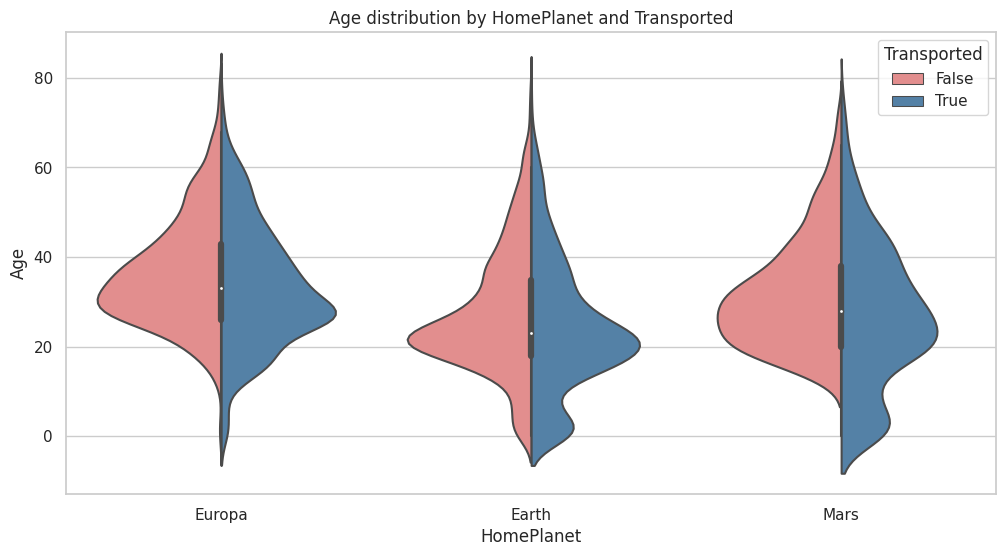

In [22]:
sns.set(style='whitegrid')
plt.figure(figsize=(12,6))
sns.violinplot(data=train, x='HomePlanet', y='Age', hue='Transported', split=True, palette={True:'steelblue', False:'lightcoral'})
plt.title('Age distribution by HomePlanet and Transported')
plt.show()

<div style="font-family: 'Segoe UI', Roboto, Arial, sans-serif; line-height: 1.7; color: #e5e7eb; max-width: 900px; background-color: transparent;">
  <div style="border-left: 4px solid #10b981; background-color: rgba(16, 185, 129, 0.08); padding: 1.2rem 1.4rem; border-radius: 10px;">
    <h3 style="color: #6ee7b7; font-weight: 600; margin-top: 0; margin-bottom: 0.8rem; font-size: 1.25rem;">
      Categorical Feature Association with Transported (Chi-Square Test)
    </h3>
    <p style="color: #d1d5db; margin-bottom: 1rem;">
      We performed chi-square tests to evaluate the relationship between categorical features and the <strong>Transported</strong> target variable. The results indicate the following:
    </p>
    <ul style="list-style-type: none; padding-left: 0; color: #d1d5db; margin: 0;">
      <li style="margin-bottom: 1rem;">
        <strong>Cabin:</strong> χ² = 6849.94, p = 0.006 → The distribution of cabins is significantly associated with transport outcomes, making it the strongest categorical predictor.
      </li>
      <li style="margin-bottom: 1rem;">
        <strong>CryoSleep:</strong> χ² = 1859.61, p < 0.001 → Passengers in CryoSleep have a highly significant relationship with being transported, confirming previous observations that CryoSleep is a dominant factor.
      </li>
      <li style="margin-bottom: 1rem;">
        <strong>HomePlanet:</strong> χ² = 324.90, p < 0.001 → The origin planet is also strongly associated with transport status, with Europa showing the highest transported proportion.
      </li>
      <li style="margin-bottom: 1rem;">
        <strong>Destination:</strong> χ² = 106.39, p < 0.001 → While less influential than CryoSleep or HomePlanet, the destination still shows a statistically significant association with transported status.
      </li>
      <li style="margin-bottom: 1rem;">
        <strong>VIP:</strong> χ² = 11.54, p = 0.00068 → VIP status has a minor but statistically significant effect on transportation outcomes.
      </li>
    </ul>
    <p style="color: #d1d5db; margin-top: 1rem;">
      <strong>Conclusion:</strong> Overall, <strong>Cabin</strong>, <strong>CryoSleep</strong>, and <strong>HomePlanet</strong> are the most influential categorical features for predicting transport outcomes, while <strong>Destination</strong> and <strong>VIP</strong> provide secondary explanatory power.
    </p>
  </div>
</div>


# 1.9 Mutual Information / Feature Importance

In [23]:
from scipy.stats import chi2_contingency

cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin']
chi_results = []

for col in cat_cols:
    ct = pd.crosstab(train[col], train['Transported'])
    chi2, p, dof, ex = chi2_contingency(ct)
    chi_results.append({'Feature': col, 'Chi2': chi2, 'p-value': p})
 
df_chi = pd.DataFrame(chi_results)
 
df_chi['p-value'] = df_chi['p-value'].apply(lambda x: round(x,6))
df_chi['Chi2'] = df_chi['Chi2'].apply(lambda x: round(x,2))
 
df_chi = df_chi.sort_values('Chi2', ascending=False)

df_chi

,Feature,Chi2,p-value
4,Cabin,6849.94,0.006047
1,CryoSleep,1859.61,0.000000
0,HomePlanet,324.90,0.000000
2,Destination,106.39,0.000000
3,VIP,11.54,0.000680
